<a href="https://colab.research.google.com/github/Jameela98/engine-performance-fault-prediction/blob/main/Copy_of_engine_faliuer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Importing required Libraries***

# New Section

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
sns.set(style="whitegrid")

***Read the file and show first five rows***

In [ ]:
df=pd.read_csv('engine_failure_dataset.csv')

In [ ]:
df.head(5)

,Time_Stamp,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Fault_Condition,Operational_Mode
0,2024-12-24 10:00:00,60.308585,3426.827588,20.445472,0.874657,0.005686,0.529798,107.877659,23.367684,2,Idle
1,2024-12-24 10:05:00,112.705055,2949.758424,23.083947,0.696461,0.391779,0.124336,60.351655,57.941022,3,Cruising
2,2024-12-24 10:10:00,108.670976,1817.971040,20.555326,0.495276,0.189714,0.886417,110.986564,47.732998,2,Cruising
3,2024-12-24 10:15:00,107.114691,2730.660539,23.226431,0.986206,0.983202,0.468114,77.416793,44.112039,2,Cruising
4,2024-12-24 10:20:00,118.075814,1854.488677,21.148226,0.710810,0.101139,0.481034,100.475881,80.681972,2,Cruising


***Describe the data set using .info() and .describe()***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time_Stamp         1000 non-null   object 
 1   Temperature (°C)   1000 non-null   float64
 2   RPM                1000 non-null   float64
 3   Fuel_Efficiency    1000 non-null   float64
 4   Vibration_X        1000 non-null   float64
 5   Vibration_Y        1000 non-null   float64
 6   Vibration_Z        1000 non-null   float64
 7   Torque             1000 non-null   float64
 8   Power_Output (kW)  1000 non-null   float64
 9   Fault_Condition    1000 non-null   int64  
 10  Operational_Mode   1000 non-null   object 
dtypes: float64(8), int64(1), object(2)
memory usage: 86.1+ KB


In [ ]:
df.describe()

,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Fault_Condition
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,90.504323,2512.321847,22.490255,0.500771,0.502289,0.483137,123.574345,58.881629,1.465000
std,17.255081,867.543649,4.422922,0.294531,0.281046,0.288449,42.897150,22.535297,1.106345
min,60.013118,1000.737383,15.045726,0.000170,0.000741,0.001086,50.059144,20.148910,0.000000
25%,75.708728,1757.938417,18.634425,0.234537,0.264195,0.233457,85.735962,40.220009,0.000000
50%,90.168595,2498.874857,22.433952,0.519200,0.503314,0.461902,122.377927,58.850054,1.000000
75%,105.478252,3273.470646,26.448111,0.752874,0.744645,0.737903,160.091056,78.345886,2.000000
max,119.982191,3996.039482,29.998912,0.999893,0.999531,0.999384,199.909402,99.932956,3.000000


***Generate the correlation matrix***

In [ ]:
numerical_df = df.select_dtypes(include=['number'])

In [ ]:
numerical_df.head(5)

,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Fault_Condition
0,60.308585,3426.827588,20.445472,0.874657,0.005686,0.529798,107.877659,23.367684,2
1,112.705055,2949.758424,23.083947,0.696461,0.391779,0.124336,60.351655,57.941022,3
2,108.670976,1817.971040,20.555326,0.495276,0.189714,0.886417,110.986564,47.732998,2
3,107.114691,2730.660539,23.226431,0.986206,0.983202,0.468114,77.416793,44.112039,2
4,118.075814,1854.488677,21.148226,0.710810,0.101139,0.481034,100.475881,80.681972,2


In [ ]:
corr_df = numerical_df.corr()
corr_df

,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Fault_Condition
Temperature (°C),1.000000,-0.034822,-0.027600,-0.037111,-0.051411,0.007875,0.014493,0.077893,-0.014316
RPM,-0.034822,1.000000,0.044257,0.027106,0.030223,0.014451,-0.084991,-0.018127,-0.008931
Fuel_Efficiency,-0.027600,0.044257,1.000000,0.012710,0.012875,-0.063480,0.019734,-0.005822,0.039064
Vibration_X,-0.037111,0.027106,0.012710,1.000000,0.004040,-0.036334,0.028512,0.040213,0.039790
Vibration_Y,-0.051411,0.030223,0.012875,0.004040,1.000000,0.006809,-0.006905,-0.054801,-0.024230
Vibration_Z,0.007875,0.014451,-0.063480,-0.036334,0.006809,1.000000,0.049617,-0.030390,-0.009072
Torque,0.014493,-0.084991,0.019734,0.028512,-0.006905,0.049617,1.000000,0.022262,0.057271
Power_Output (kW),0.077893,-0.018127,-0.005822,0.040213,-0.054801,-0.030390,0.022262,1.000000,0.043560
Fault_Condition,-0.014316,-0.008931,0.039064,0.039790,-0.024230,-0.009072,0.057271,0.043560,1.000000


***Generate heatmap to explain the correlation among variables***

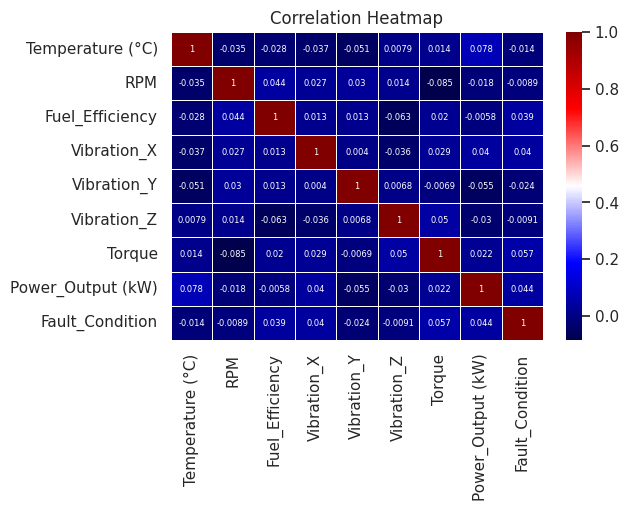

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr_df, annot=True, cmap='seismic', linewidths=0.5,annot_kws={"size": 6})
plt.title('Correlation Heatmap')
plt.show()
plt.tight_layout()

***Some another visualizations***

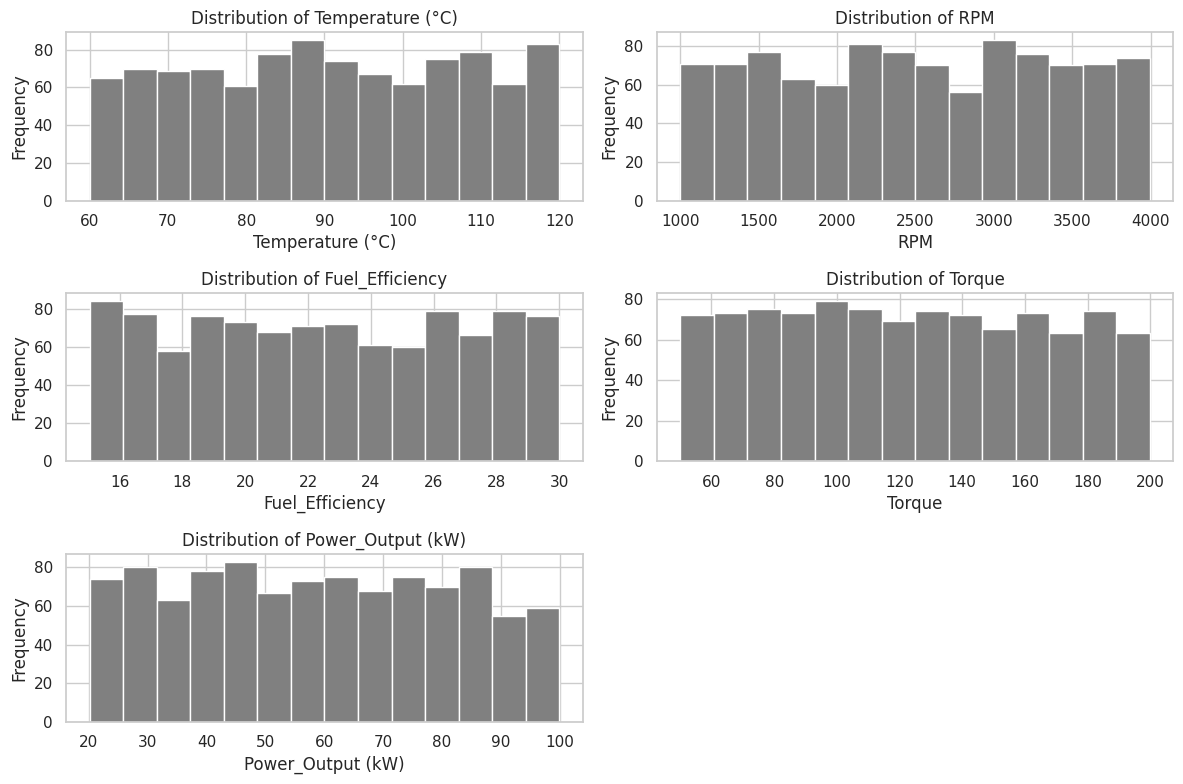

In [ ]:
numerical_columns = ['Temperature (°C)', 'RPM', 'Fuel_Efficiency', 'Torque', 'Power_Output (kW)'	]

plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 2, i)  # Arrange subplots in a grid (2 rows, 2 columns)
    sns.histplot(df[col], kde=False, bins=14, color='grey', alpha=1)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
categorical_columns=df[['Fault_Condition'	,'Operational_Mode']]

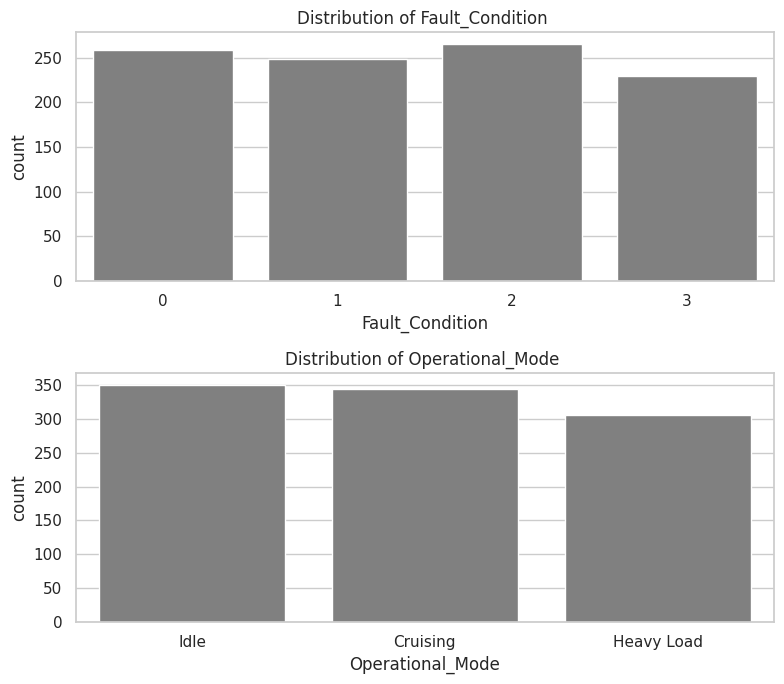

In [ ]:
plt.figure(figsize=(8,7))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(2, 1, i)  # Arrange subplots in a grid (2 rows, 2 columns)
    sns.countplot(data=df, x=col,color='grey')
    plt.title(f'Distribution of {col} ')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

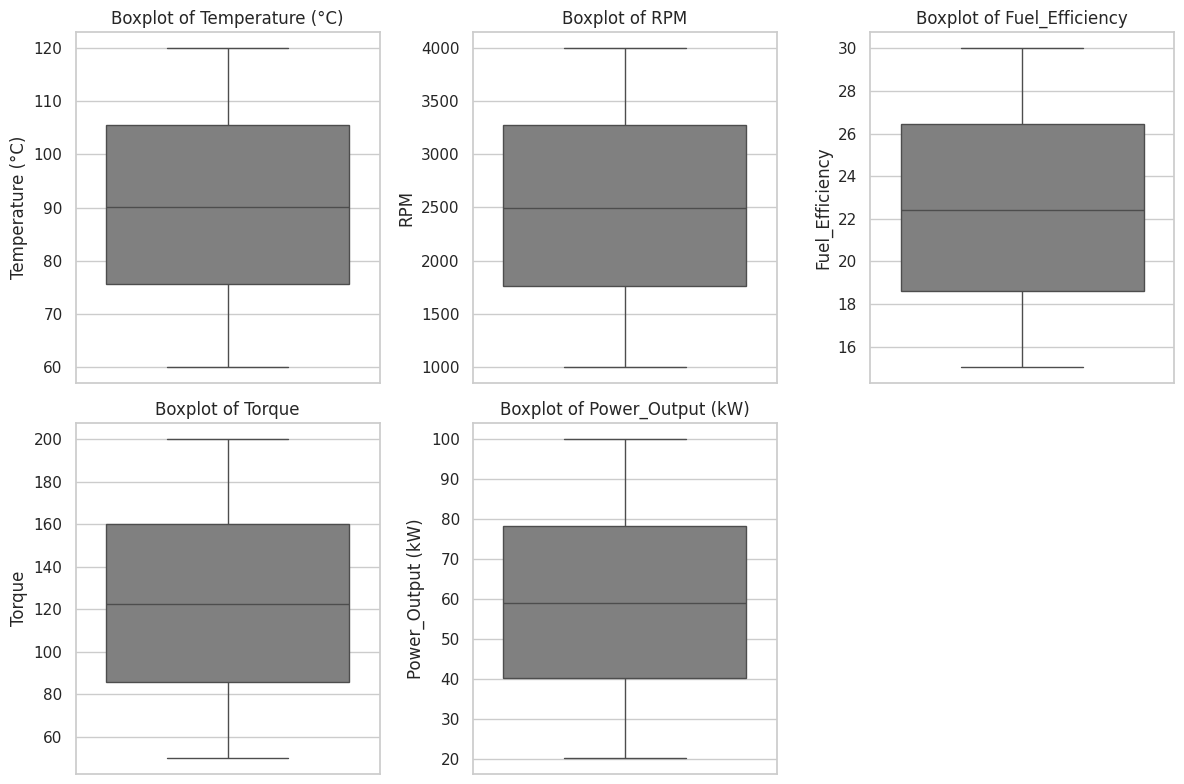

In [ ]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, y=col, color='grey')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

***Define relationship between specific columns***

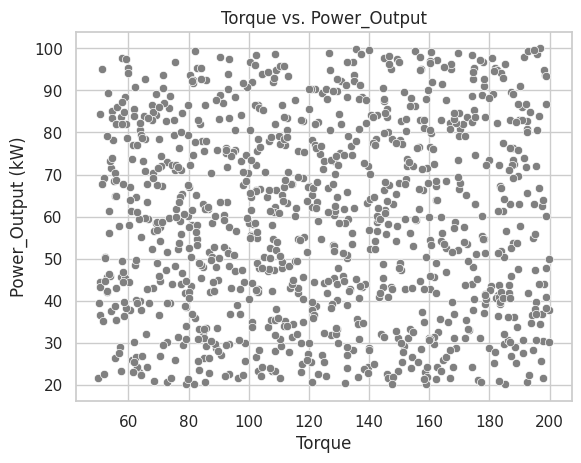

In [ ]:
sns.scatterplot(data=df, x='Torque', y='Power_Output (kW)'	, color='grey')
plt.title('Torque vs. Power_Output')
plt.show()

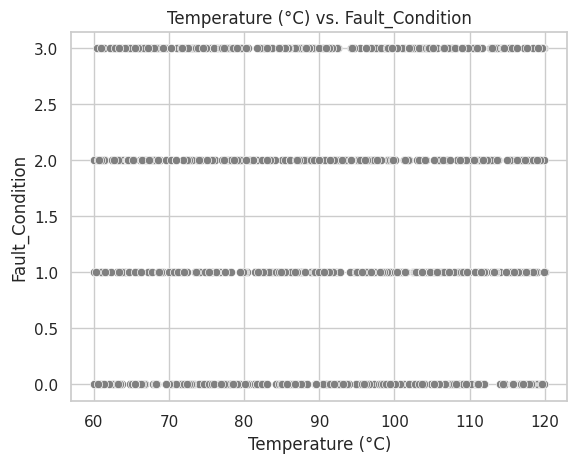

In [ ]:
sns.scatterplot(data=df, x='Temperature (°C)', y='Fault_Condition'	, color='grey')
plt.title('Temperature (°C) vs. Fault_Condition')
plt.show()


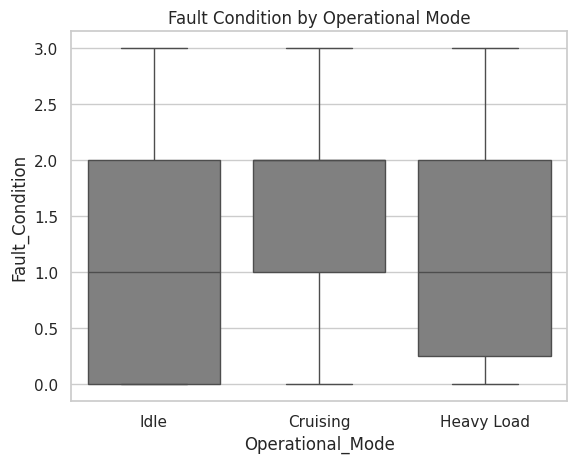

In [ ]:
sns.boxplot(data=df,x='Operational_Mode' ,y='Fault_Condition',color='grey')
plt.title('Fault Condition by Operational Mode')
plt.ylabel('Fault_Condition')
plt.show()


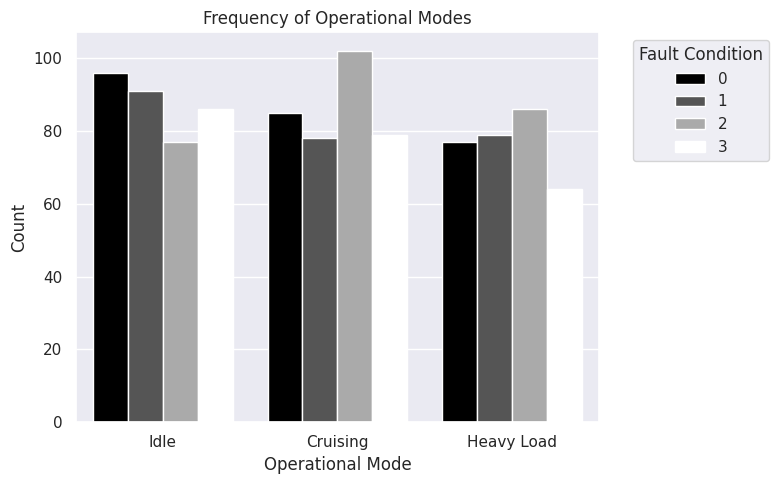

In [ ]:
sns.set(style="darkgrid")
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Operational_Mode',hue='Fault_Condition', palette='gray')
plt.title('Frequency of Operational Modes')
plt.xlabel('Operational Mode')
plt.ylabel('Count')
plt.legend(title='Fault Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**creat pivot_table**

In [ ]:
from google.colab import data_table
data_table.enable_dataframe_formatter()

In [ ]:
df_pivot=df.pivot_table(index='Operational_Mode', columns='Fault_Condition', values='Time_Stamp', aggfunc='count')
df_pivot

Fault_Condition,0,1,2,3
Operational_Mode,,,,
Cruising,85,78,102,79
Heavy Load,77,79,86,64
Idle,96,91,77,86


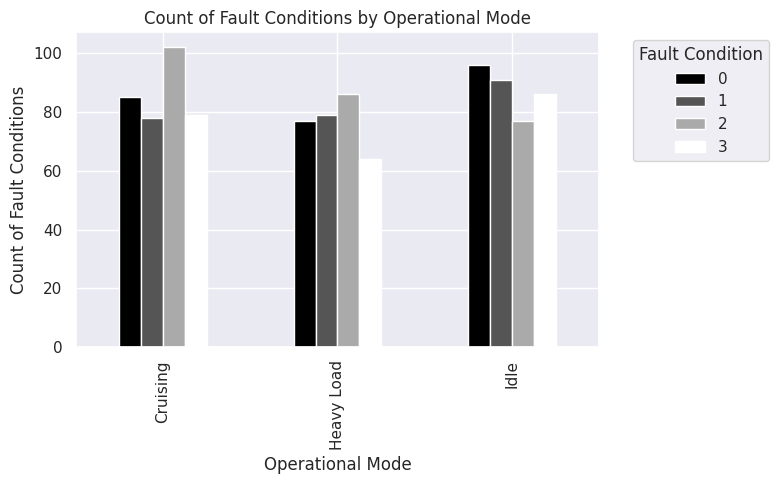

In [ ]:
sns.set(style="darkgrid")
df_pivot_reset = df_pivot.reset_index()

# Plot grouped bar chart
df_pivot_reset.plot(x='Operational_Mode', kind='bar', figsize=(8, 5), colormap='grey')
plt.title('Count of Fault Conditions by Operational Mode')
plt.xlabel('Operational Mode')
plt.ylabel('Count of Fault Conditions')
plt.legend(title='Fault Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import data_table
data_table.disable_dataframe_formatter()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [ ]:
df_scaled=scaler.fit_transform(df[['Temperature (°C)', 'RPM', 'Fuel_Efficiency', 'Torque', 'Power_Output (kW)']])
df_scaled=pd.DataFrame(df_scaled,columns=['Temperature (°C)', 'RPM', 'Fuel_Efficiency', 'Torque', 'Power_Output (kW)'])
df_scaled.head()


,Temperature (°C),RPM,Fuel_Efficiency,Torque,Power_Output (kW)
0,0.004927,0.809965,0.361110,0.385842,0.040344
1,0.878652,0.650693,0.537559,0.068685,0.473680
2,0.811383,0.272838,0.368457,0.406589,0.345734
3,0.785431,0.577545,0.547088,0.182567,0.300350
4,0.968211,0.285030,0.408107,0.336447,0.758711


In [ ]:
opera_mode=pd.get_dummies(df['Operational_Mode'],dtype=int)
opera_mode.head()

,Cruising,Heavy Load,Idle
0,0,0,1
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


In [ ]:
x=df_scaled.join(df[['Vibration_X','Vibration_Y','Vibration_Z']]).join(opera_mode)
y=df['Fault_Condition']

In [ ]:
#from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
RandomForestClassifier=RandomForestClassifier()

In [ ]:
RandomForestClassifier.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred = RandomForestClassifier.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy=accuracy_score(y_test,y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.24


In [ ]:
print("classification_report:\n",classification_report(y_test,y_pred))

classification_report:
               precision    recall  f1-score   support

           0       0.18      0.41      0.25        32
           1       0.30      0.26      0.28        58
           2       0.27      0.19      0.22        62
           3       0.24      0.17      0.20        48

    accuracy                           0.24       200
   macro avg       0.25      0.26      0.24       200
weighted avg       0.26      0.24      0.24       200



In [ ]:
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))

confusion_matrix:
 [[13  7  6  6]
 [21 15 15  7]
 [23 15 12 12]
 [15 13 12  8]]


In [ ]:
df['Fault_Condition'].value_counts()


,count
Fault_Condition,
2,265
0,258
1,248
3,229


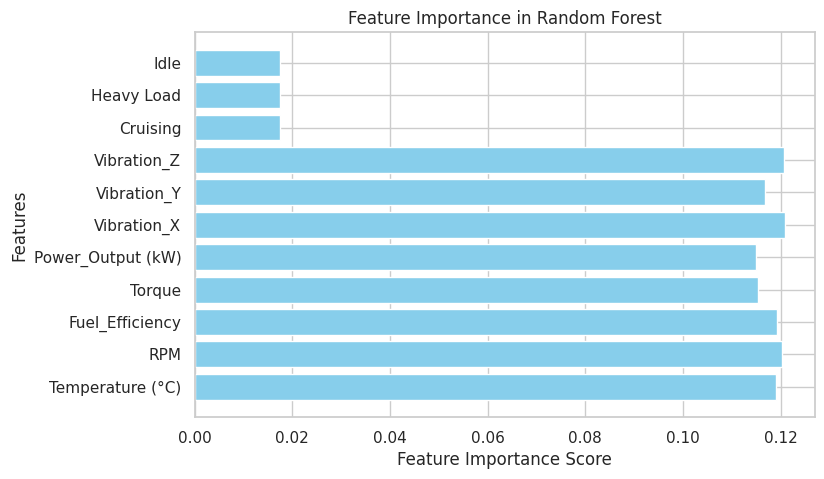

In [ ]:
import matplotlib.pyplot as plt
importances = RandomForestClassifier.feature_importances_

# Plot feature importance
plt.figure(figsize=(8,5))
plt.barh(x.columns, importances, color='skyblue')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance in Random Forest')
plt.show()


In [ ]:
x1=df_scaled.join(df[['Vibration_X','Vibration_Y','Vibration_Z']])
y1=df['Fault_Condition']

In [ ]:
x_train1,x_test1,y_train1,y_test1=train_test_split(x1,y1,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
RandomForestClassifier1=RandomForestClassifier()

In [ ]:
pip install imbalanced-learn


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


In [ ]:
smote = SMOTE(sampling_strategy='auto', random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)
print(y_train_smote.value_counts())


Fault_Condition
1    226
3    226
0    226
2    226
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
RandomForestClassifier1.fit(x_train1,y_train1)

RandomForestClassifier()

In [ ]:
y_pred1 = RandomForestClassifier1.predict(x_test1)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy1=accuracy_score(y_test1,y_pred1)
print(f'Accuracy1: {accuracy:.2f}')

Accuracy1: 0.24


In [ ]:
print("classification_report1:\n",classification_report(y_test1,y_pred1))

classification_report1:
               precision    recall  f1-score   support

           0       0.15      0.41      0.22        32
           1       0.30      0.22      0.26        58
           2       0.22      0.13      0.16        62
           3       0.28      0.19      0.23        48

    accuracy                           0.21       200
   macro avg       0.24      0.24      0.22       200
weighted avg       0.25      0.21      0.21       200



In [ ]:
print("confusion_matrix1:\n",confusion_matrix(y_test1,y_pred1))

confusion_matrix1:
 [[13  6 11  2]
 [26 13  9 10]
 [30 13  8 11]
 [19 11  9  9]]


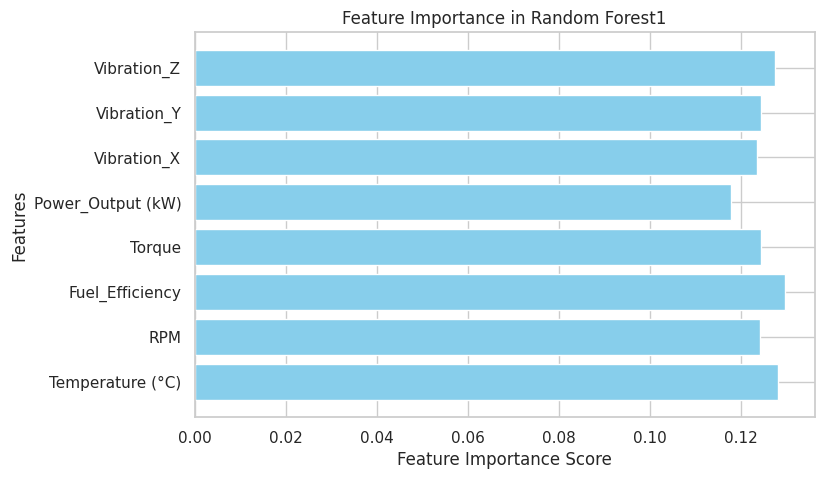

In [ ]:
import matplotlib.pyplot as plt
importances = RandomForestClassifier1.feature_importances_

# Plot feature importance
plt.figure(figsize=(8,5))
plt.barh(x1.columns, importances, color='skyblue')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance in Random Forest1')
plt.show()
